In [44]:
import scanpy as sc
import hdf5plugin
import anndata as ad

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn.objects  as so

from scipy.stats import chi2_contingency, false_discovery_control, mannwhitneyu
from scipy.stats import pearsonr,spearmanr
from sklearn.metrics import mean_squared_error, r2_score

import decoupler as dc
import os

from tqdm import tqdm

In [2]:
import importlib
importlib.reload(dc)

<module 'decoupler' from '/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/decoupler/__init__.py'>

In [2]:
import plotting_funs
prop_cycle = plotting_funs.set_mpl_attributes()

# Load Data:

In [45]:
def ctrl_pert_split_dataset(norm_data: ad.AnnData) -> tuple[list[str], dict[str,list[str]]]:
    # Split df into perturbed and control cells
    by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
    # Find indices for each perturbation
    pert_i_dict = {pert.iloc[0]["perturbation"]:pert.index.to_list() for pert in by_pert}
    # Extract the control cells separately
    ctrl_i_vec = pert_i_dict.pop("ctrl")
    return (ctrl_i_vec, pert_i_dict)

In [46]:
grn_file = "KeggoRo_noG"
names = ["Norman19","Replogle22"]
models = ["experimental","pGRiNS"]#, "Random"]

models_rand = ["pGRiNS","Random"]

In [ ]:
data = {}
for name in names:
    data[name] = {}
    for model in models:
        data[name][model] = {}
    data[name]["experimental"]["adata"] = sc.read_h5ad(f"../Data/Experimental/{name}/perturb_norm_subset_{grn_file}.h5ad")
    #perts = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())[:10]
    #data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][data[name]["experimental"]["adata"].obs["perturbation"].isin(["ctrl"]+perts)]

pgrins_full = sc.read_h5ad(f"../Data/Projects/{grn_file}/001/perturb_norm_full.h5ad")
data["Norman19"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["perturbation"].isin(data["Norman19"]["experimental"]["adata"].obs["perturbation"]),sorted(list(set(data["Norman19"]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]
data["Replogle22"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["perturbation"].isin(data["Replogle22"]["experimental"]["adata"].obs["perturbation"]),sorted(list(set(data["Replogle22"]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]

for name in names:
    data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][:,sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(data[name]["pGRiNS"]["adata"].var_names)))]
    data[name]["perts"] = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())
    data[name]["perts"].remove("ctrl")
    for model in models:
        data[name][model]["pert_indices"] = ctrl_pert_split_dataset(data[name][model]["adata"])
        data[name][model]["pert_means"] = {pert : np.asarray(np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"],axis=0)).squeeze() for pert in tqdm(data[name]["perts"])}

/tmp/ipykernel_25756/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 24/24 [00:07<00:00,  3.05it/s]
/tmp/ipykernel_25756/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 24/24 [00:01<00:00, 21.23it/s]
/tmp/ipykernel_25756/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

# Qualitative comparison:

## Visual comparison:

In [48]:
perts = list(pgrins_full.obs["perturbation"].unique())
perts.remove("ctrl")

In [49]:
pgenes = set().union(*[set(p.split("_")) for p in perts])

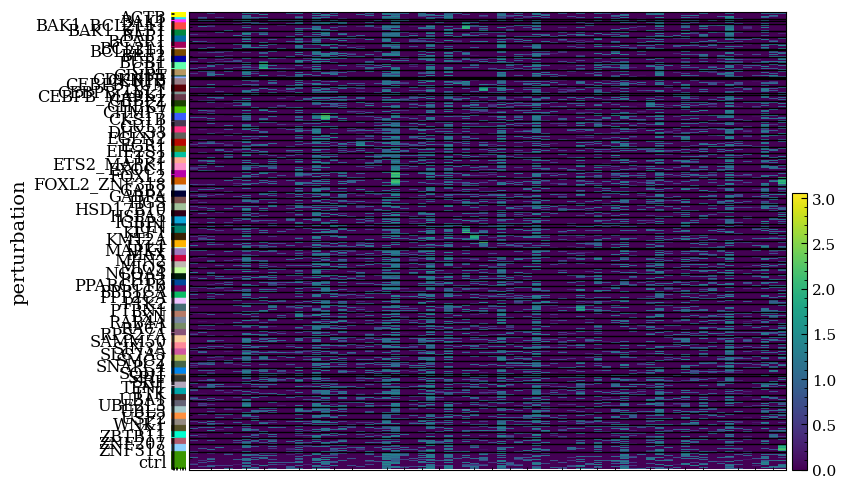

In [50]:
sc.pl.heatmap(pgrins_full,sorted(list(pgenes)),"perturbation",layer="log1p")

## Value distributions:

### Means:

In [51]:
# Visualize correlation between means:
spearman_mean_correlation = []
for name in names:
    for pert in data[name]["perts"]:
        spearman_mean_correlation.append(spearmanr(data[name]["experimental"]["pert_means"][pert],data[name]["pGRiNS"]["pert_means"][pert]).correlation)

(array([1., 0., 1., 0., 2., 0., 0., 2., 1., 1., 5., 1., 1., 3., 1., 8., 5.,
        2., 0., 2., 4., 3., 6., 9., 2., 5., 4., 1., 1., 4.]),
 array([-0.02208803, -0.02006118, -0.01803433, -0.01600748, -0.01398063,
        -0.01195378, -0.00992693, -0.00790008, -0.00587322, -0.00384637,
        -0.00181952,  0.00020733,  0.00223418,  0.00426103,  0.00628788,
         0.00831473,  0.01034158,  0.01236843,  0.01439528,  0.01642213,
         0.01844898,  0.02047583,  0.02250268,  0.02452953,  0.02655638,
         0.02858323,  0.03061009,  0.03263694,  0.03466379,  0.03669064,
         0.03871749]),
 <BarContainer object of 30 artists>)

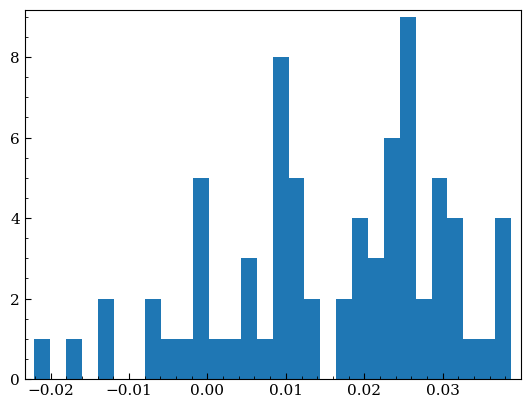

In [52]:
plt.hist(spearman_mean_correlation,bins=30)

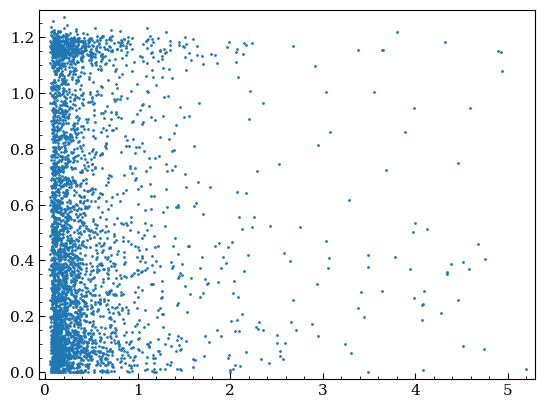

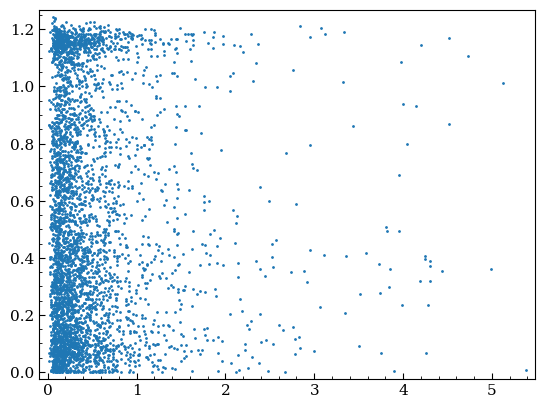

In [53]:
i = 3
for name in names:
    plt.scatter(data[name]["experimental"]["pert_means"][data[name]["perts"][i]],data[name]["pGRiNS"]["pert_means"][data[name]["perts"][i]],s=1)
    plt.show()

### Pert LogFCs:

In [54]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="ctrl",key_added="vs_ctrl",layer="log1p")
        data[name][model]["pgene_logFC"] = []
        for pert in data[name]["perts"]:
            pg_pert = pert.split("_")
            data[name][model]["pgene_logFC"].append(np.mean([data[name][model]["adata"].uns["vs_ctrl"]["logfoldchanges"][pert][data[name][model]["adata"].uns["vs_ctrl"]["names"][pert]==pg] for pg in pg_pert]))

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

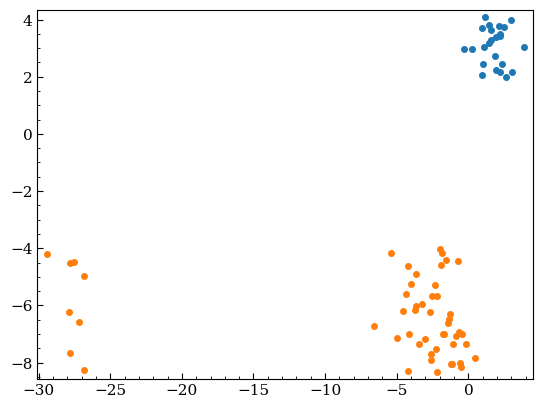

In [55]:
plt.scatter(data["Norman19"]["experimental"]["pgene_logFC"],data["Norman19"]["pGRiNS"]["pgene_logFC"])
plt.scatter(data["Replogle22"]["experimental"]["pgene_logFC"],data["Replogle22"]["pGRiNS"]["pgene_logFC"])

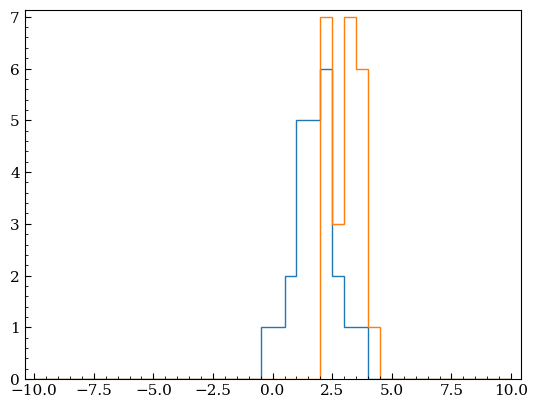

In [58]:
bins = 20
plt.stairs(*np.histogram(data["Norman19"]["experimental"]["pgene_logFC"],bins=2*bins,range=(-10,10)))
plt.stairs(*np.histogram(data["Norman19"]["pGRiNS"]["pgene_logFC"],bins=2*bins,range=(-10,10)))
plt.show()

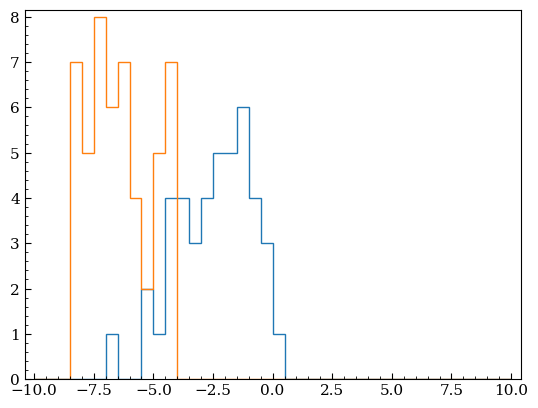

In [57]:
bins = 20
plt.stairs(*np.histogram(data["Replogle22"]["experimental"]["pgene_logFC"],bins=2*bins,range=(-10,10)))
plt.stairs(*np.histogram(data["Replogle22"]["pGRiNS"]["pgene_logFC"],bins=2*bins,range=(-10,10)))
plt.show()

In [ ]:
# Observation: For KeggoRo_0206, In Norman19, a pert scale factor of 100 lead to slightly higher logFCs (but all positive)
# while in Replogle22, a factor of 1/100 also lead to higher logFC (many of which are positive, although they should be negative)
# the opposite was the case for doro_abcd_only
# this was before pert affected the whole ODE (-> prob for Replogle, the lower -kC caused the expression lvl to rebound or sth)

# Shared DEGs:

In [59]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis",rankby_abs=True,layer="log1p")
        data[name][model]["DEGs"] = {pert : data[name][model]["adata"].uns["DEG_analysis"]["names"][pert][data[name][model]["adata"].uns["DEG_analysis"]["pvals_adj"][pert] < 0.05] for pert in tqdm(data[name]["perts"])}
        #data[name][model]["ON_genes"] = {pert : data[name][model]["adata"].var_names[data[name][model]["pert_means"][pert]>np.mean(data[name][model]["pert_means"][pert])] for pert in tqdm(data[name]["perts"])}
    data[name]["Random"] = {}
    data[name]["Random"]["DEGs"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["DEGs"][pert])) for pert in tqdm(data[name]["perts"])}
    #data[name]["Random"]["ON_genes"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["ON_genes"][pert])) for pert in tqdm(data[name]["perts"])}

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:462: PerformanceWarning: Da

In [60]:
chisq_res = {}
for test in ["DEGs"]:#,"ON_genes"]:
    chisq_res[test] = {}
    for model in ["pGRiNS","Random"]:
        chisq_res[test][model] = {}
        chisq_res[test][model]["pvals"] = []
        for name in names:
            for pert in data[name]["perts"]:
                genes_exp_set = set(data[name]["experimental"][test][pert])
                all_genes = set(data[name]["experimental"]["adata"].var_names)
                genes_model_set = set(data[name][model][test][pert])
                # Get contingency matrix
                count_matrix = np.array([[len(genes_exp_set & genes_model_set),len(genes_model_set - genes_exp_set)],[len(genes_exp_set - genes_model_set),len(all_genes - (genes_exp_set|genes_model_set))]])
                res = chi2_contingency(count_matrix)
                chisq_res[test][model]["pvals"].append(res.pvalue)
        chisq_res[test][model]["pvals_adj"] = false_discovery_control(chisq_res[test][model]["pvals"]) # Benjamini-Hochberg correction due to large number of p values
        


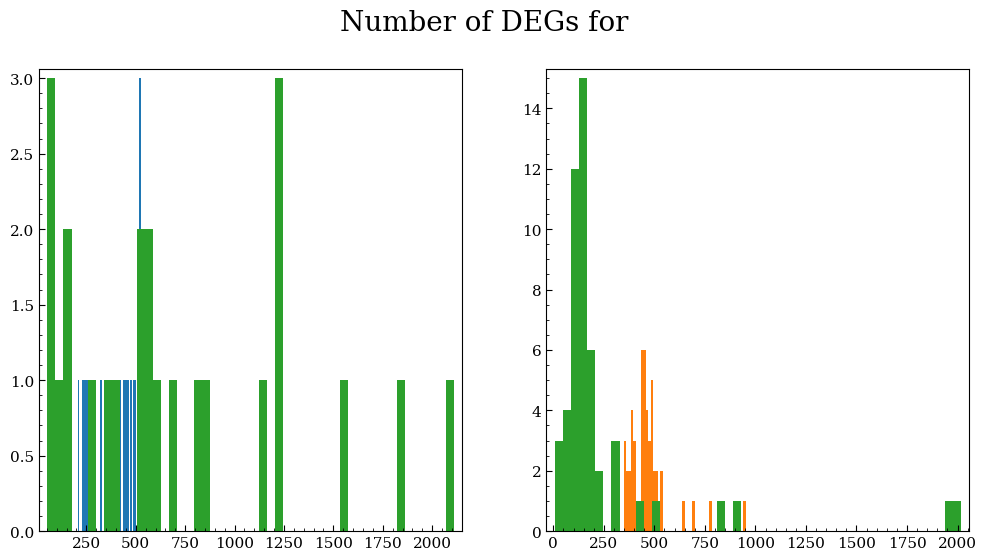

In [61]:
fig, axs = plt.subplots(1,2,figsize=(12,6))
axs[0].hist([len(x) for x in data["Norman19"]["pGRiNS"]["DEGs"].values()],bins=50,color=prop_cycle[0])
axs[0].hist([len(x) for x in data["Norman19"]["experimental"]["DEGs"].values()],bins=50,color=prop_cycle[2])
axs[1].hist([len(x) for x in data["Replogle22"]["pGRiNS"]["DEGs"].values()],bins=50,color=prop_cycle[1])
axs[1].hist([len(x) for x in data["Replogle22"]["experimental"]["DEGs"].values()],bins=50,color=prop_cycle[2])
plt.suptitle("Number of DEGs for ")
plt.show()
# Maybe scatterplot with id line?

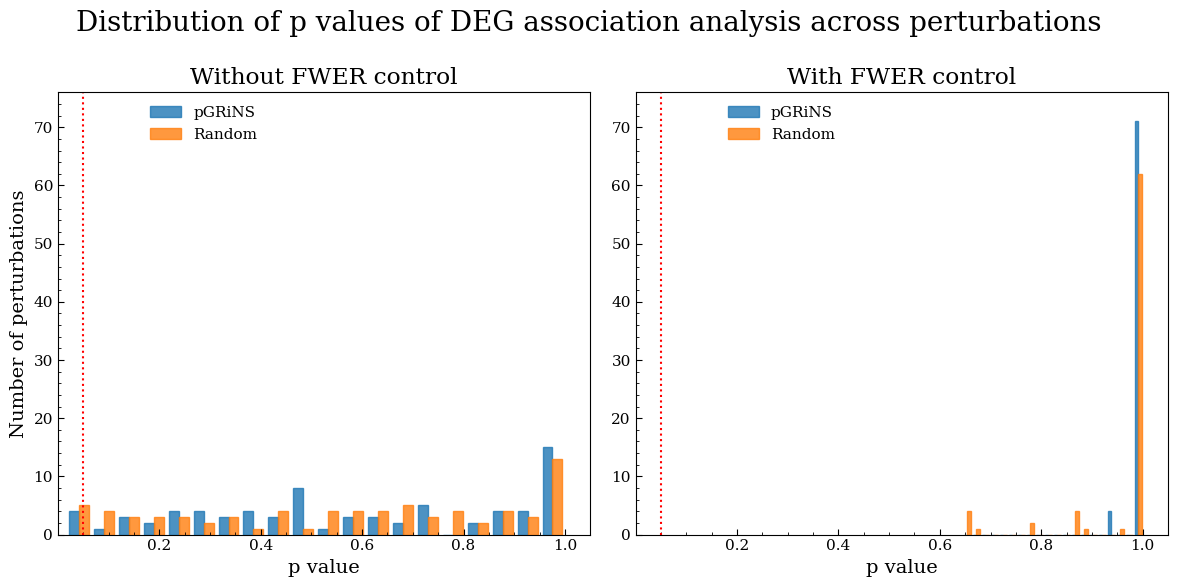

In [62]:
fig, axs = plt.subplots(1,2,figsize=(12,6))
axs[0].hist([chisq_res["DEGs"]["pGRiNS"]["pvals"],chisq_res["DEGs"]["Random"]["pvals"]],bins=20,label=["pGRiNS","Random"],color=[prop_cycle[0],prop_cycle[1]],alpha=0.8,lw=1,edgecolor=[prop_cycle[0],prop_cycle[1]])
axs[0].vlines(0.05,0,76,color="red",linestyles="dotted")
axs[0].set_ylim(0,76)
axs[0].set_xlim(0.000001,1.05)
axs[0].set_title("Without FWER control")
axs[0].legend(bbox_to_anchor=(0.4,1))
axs[0].set_ylabel("Number of perturbations")
axs[0].set_xlabel("p value")

axs[1].hist([chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"]],label=["pGRiNS","Random"],bins=20,color=[prop_cycle[0],prop_cycle[1]],alpha=0.8,lw=1,edgecolor=[prop_cycle[0],prop_cycle[1]])
axs[1].vlines(0.05,0,76,color="red",linestyles="dotted")
axs[1].set_ylim(0,76)
axs[1].set_xlim(0.0000001,1.05)
axs[1].set_title("With FWER control")
axs[1].legend(bbox_to_anchor=(0.4,1))
axs[1].set_xlabel("p value")
fig.suptitle("Distribution of p values of DEG association analysis across perturbations")
fig.tight_layout()
os.makedirs(f"Plots/{grn_file}/001",exist_ok=True)
plt.savefig(f"Plots/{grn_file}/001/DEG_pvals.png")
plt.show()

In [63]:
u_deg = mannwhitneyu(chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"],alternative="two-sided")
print(u_deg.pvalue) # 2.718303674376062e-08

0.00860103749636963


# Compare using metrics:

In [20]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis_Mejia",method="t-test_overestim_var",layer="log1p")
    
        data[name][model]["weights_Mejia"] = {}
        for pert in data[name]["perts"]:
            pert_weights = data[name][model]["adata"].uns["DEG_analysis_Mejia"]["scores"][pert]
            pert_weights = np.abs(pert_weights) # Absolute value transformation
            pert_weights = (pert_weights-min(pert_weights))/(max(pert_weights)-min(pert_weights)+1e-8) # Min-max transformation to [0,1]
            pert_weights = pert_weights**2 # Squaring
            pert_weights = pert_weights/sum(pert_weights) # Normalization
            pert_weights = pert_weights[np.argsort(data[name][model]["adata"].uns["DEG_analysis_Mejia"]["names"][pert])] # Bring them in the correct order (so that the corresponding genes are ordered alphabetically)
            data[name][model]["weights_Mejia"][pert] = pert_weights
        

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:462: PerformanceWarning: Da

In [21]:
metrics = {
    "MSE\n(↓)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : mean_squared_error(avg_expr_GT_pert, avg_expr_pred),
    "wMSE\n(↓)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2),
    "Pearson\n(↑)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : pearsonr(x=avg_expr_GT_pert, y=avg_expr_pred).correlation,
    "Pearson Delta\n(↑)":lambda avg_expr_GT_pert,avg_expr_pred, mean_unperturbed,weights : 0.0 if (avg_expr_pred == mean_unperturbed).all() else pearsonr(x=avg_expr_GT_pert-mean_unperturbed, y=avg_expr_pred-mean_unperturbed).correlation,
    "Weighted Delta R2\n(↑)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: 1-(np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2))/(np.dot(weights,(avg_expr_GT_pert-mean_unperturbed-np.dot(weights,(avg_expr_GT_pert-mean_unperturbed)))**2)) # 0.0 if (avg_expr_pred == mean_unperturbed).all() else 
    }

metric_names = list(metrics.keys())
#metric_names = metric_names[:4]

In [22]:
# For every perturbation: calculate the WMSE between the experimental data mean and each cell of the model
cellwise_metric = {}
for name in names:
    print(name)
    cellwise_metric[name] = {}
    for model in models:
        exp_pert_mean = np.mean(np.vstack(list(data[name][model]["pert_means"].values())),axis=0) # µ_all
        print(model)
        cellwise_metric[name][model] = {}
        for m in metric_names:
            print(m)
            cellwise_metric[name][model][m] = []
            for pert in tqdm(data[name]["perts"]):
                cell_mean = np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"].todense(),axis=0)
                m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(cell_mean).squeeze(),exp_pert_mean,data[name][model]["weights_Mejia"][pert])
                cellwise_metric[name][model][m].append(m_mean)
    # Negative baseline: WMSE between each experimental control cell and the experimental data mean
    cellwise_metric[name]["ctrl_baseline"] = {}
    print("ctrl_baseline")
    control_mean = np.mean(data[name]["experimental"]["adata"][data[name]["experimental"]["pert_indices"][0]].layers["log1p"].todense(),axis=0)
    for m in metric_names:
        print(m)
        cellwise_metric[name]["ctrl_baseline"][m] = []
        for pert in tqdm(data[name]["perts"]):
            m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(control_mean).squeeze(),exp_pert_mean,data[name][model]["weights_Mejia"][pert])
            cellwise_metric[name]["ctrl_baseline"][m].append(m_mean)

# Hypothesis: all normally distributed, mu_p,exp < mu_p,pgrins << mu_c,exp

# is the order of pval_adj or t score alphabetically? Or are they reordered according to pval?

Norman19
experimental
MSE
(↓)


100%|██████████| 24/24 [00:05<00:00,  4.60it/s]


wMSE
(↓)


100%|██████████| 24/24 [00:05<00:00,  4.26it/s]


Pearson
(↑)


...

100%|██████████| 51/51 [00:00<00:00, 786.52it/s]


Pearson Delta
(↑)


100%|██████████| 51/51 [00:00<00:00, 674.57it/s]


Weighted Delta R2
(↑)


100%|██████████| 51/51 [00:00<00:00, 6284.25it/s]


In [109]:
# Add red line for MSE mean (as well as Pearson etc.) of clustering by looking at ctrl of pGRiNS

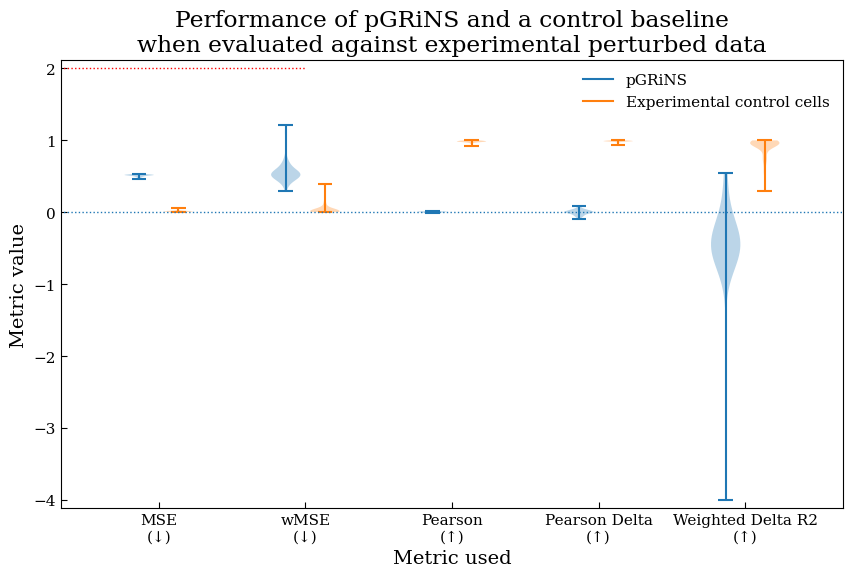

In [25]:
def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)
    plt.setp(bp['medians'], color=color)
plt.figure(figsize=(1.75*len(metric_names),6))
bpl = plt.violinplot([cellwise_metric["Norman19"]["pGRiNS"][m]+cellwise_metric["Replogle22"]["pGRiNS"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0-0.4, widths=0.6)
bpr = plt.violinplot([cellwise_metric["Norman19"]["ctrl_baseline"][m]+cellwise_metric["Replogle22"]["ctrl_baseline"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0+0.4, widths=0.6)
plt.plot([], c=prop_cycle[0], label='pGRiNS')
plt.plot([], c=prop_cycle[1], label='Experimental control cells')
plt.hlines(0,-3, len(metric_names) * 3,linestyles="dotted",lw=1)
plt.hlines(2,-3, 3,linestyles="dotted",lw=1,color="r")
plt.legend()
#set_box_color(bpl, prop_cycle[0])
#set_box_color(bpr, prop_cycle[1])
#plt.ylim(-1,1)import plotting_funs
plt.xticks(range(0, len(metric_names) * 3, 3),metric_names)# [metric_names[0]+" (↓)",metric_names[1]+" (↓)",metric_names[2]+" (↑)"])
plt.tick_params(which='minor', length=0)
plt.xlim(-3+1, len(metric_names)*3-1)
plt.title("Performance of pGRiNS and a control baseline\nwhen evaluated against experimental perturbed data")
plt.xlabel("Metric used")
plt.ylabel("Metric value")
plt.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/metrics2.png")
plt.show()

# Pathways:

## GSEA:

- Inspired from https://www.sc-best-practices.org/conditions/gsea_pathway.html

In [28]:
# Retrieving via python
msigdb = dc.op.resource("MSigDB")

# Get reactome pathways
reactome = msigdb.query("collection == 'reactome_pathways'")
# Filter duplicates
reactome = reactome[~reactome.duplicated(("geneset", "genesymbol"))].rename(columns={"genesymbol":"target","geneset":"source"})

In [29]:
data[name][model]["adata"]

AnnData object with n_obs × n_vars = 9045 × 3919
    obs: 'PertNum', 'InitCondNum', 'ParamNum', 'SteadyStateFlag', 'Time', 'perturbation', 'cell_line', 'cell_type', 'condition', 'condition_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes'
    var: 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'vs_ctrl', 'DEG_analysis', 'DEG_analysis_Mejia'
    layers: 'log1p', 'missing_matrix'

In [30]:
gsea_dict = {}
for name in names:
    gsea_dict[name] = {}
    # Filter reactome by genes in each dataset
    gsea_dict[name]["reactome"] = reactome[reactome["target"].isin(data[name]["experimental"]["adata"].var_names)]
    # Get the genesets with no. of genes in [15,500]
    geneset_size = gsea_dict[name]["reactome"].groupby("source").size()
    gsea_dict[name]["genesets"] = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)] # ~600 genesets for both datasets
    for model in models:
        gsea_dict[name][model] = {}
        for pert in tqdm(data[name]["perts"]):
            t_stats = sc.get.rank_genes_groups_df(data[name][model]["adata"], pert, key="DEG_analysis").set_index("names").sort_values("scores", key=np.abs, ascending=False)[["scores"]].rename_axis([pert], axis=1)
            scores, pvals = dc.mt.gsea(
                t_stats.T,
                gsea_dict[name]["reactome"][gsea_dict[name]["reactome"]["source"].isin(gsea_dict[name]["genesets"])],
            )
            gsea_dict[name][model][pert] = (
                pd.concat({"score": scores.T, "pval": pvals.T}, axis=1)
                .droplevel(level=1, axis=1)
                .sort_values("pval")
            )

100%|██████████| 10/10 [00:50<00:00,  5.07s/it]


In [ ]:
# score instead of pval!!!

In [197]:
gsea_dict[name]["pGRiNS"]["CHEK1"]

,score,pval
REACTOME_L1CAM_INTERACTIONS,-1.253399,0.00000
REACTOME_COLLAGEN_FORMATION,-1.924615,0.00000
REACTOME_DRUG_ADME,1.761555,0.00000
REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION,-1.418733,0.00000
REACTOME_CRISTAE_FORMATION,1.628141,0.37508
...,...,...
REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY,-1.035959,1.00000
REACTOME_VESICLE_MEDIATED_TRANSPORT,0.967027,1.00000
REACTOME_VIRAL_INFECTION_PATHWAYS,0.971306,1.00000
REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS,0.849588,1.00000


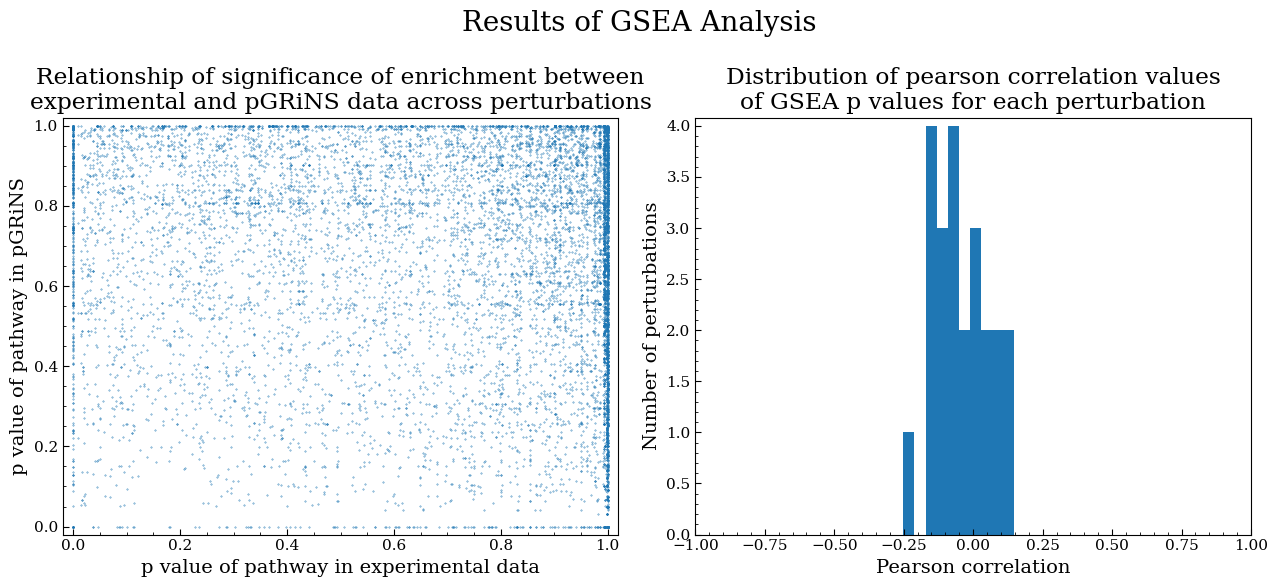

In [32]:
gsea_pearsons = []
fig,axs=plt.subplots(1,2,figsize=(13,6))
for name in names:
    for pert in data[name]["perts"]:
        gsea_pearsons.append(pearsonr(gsea_dict[name]["experimental"][pert].sort_index().pval,gsea_dict[name]["pGRiNS"][pert].sort_index().pval).correlation)
        axs[0].scatter(gsea_dict[name]["experimental"][pert].sort_index().pval,gsea_dict[name]["pGRiNS"][pert].sort_index().pval,s=0.1,c=prop_cycle[0])
    axs[0].set_ylabel("p value of pathway in pGRiNS")
    axs[0].set_xlabel("p value of pathway in experimental data")
    axs[0].set_title("Relationship of significance of enrichment between\nexperimental and pGRiNS data across perturbations")
    axs[1].hist(gsea_pearsons,bins=10,color=prop_cycle[0])
    axs[1].set_xlim(-1,1)
    axs[1].set_title("Distribution of pearson correlation values\nof GSEA p values for each perturbation")
    axs[1].set_ylabel("Number of perturbations")
    axs[1].set_xlabel("Pearson correlation")
fig.suptitle("Results of GSEA Analysis")
fig.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/gsea.png")
plt.show()

## Coexpression Graph:
- Inspired from https://link.springer.com/protocol/10.1007/978-1-0716-2067-0_19

- Both GO analysis on modules, and graph comparison with CoDiNA
    - GSEA is done perturbation wise (can pGRiNS capture the specific pathways affected by a perturbation?)
    - GO is done across perturbations (are genes generally coexpressed in such a way that networks/pathways are derivable?   )

In [ ]:
# Prepare data for original GRN:
full_topo = pd.concat([pd.read_csv(f"../Data/Projects/{grn_file}/001/{grn_file}_sinks.topo",sep=" "),pd.read_csv(f"../Data/Projects/{grn_file}/001/{grn_file}.topo",sep=" ")])
full_topo = full_topo[full_topo["Target"]!="dummy"].loc[:,["Source","Target"]]
full_topo["wTO"] = 1

for name in names:
    for model in models:
        pert_mean_matrix = pd.DataFrame(np.vstack(list(data[name][model]["pert_means"].values())),columns=data[name][model]["adata"].var_names)
        pert_mean_matrix.to_csv(f"../Data/Experimental/{name}/{name}-{model}_pert_mean.csv",sep=" ",index=False)
    genes = data[name][model]["adata"].var_names
    genes_dict = {genes[i]:i for i in range(len(genes))}
    full_topo_dataset = full_topo[(full_topo["Source"].isin(genes))&full_topo["Target"].isin(genes)]
    adj = np.eye(len(genes)).astype(bool)
    for i, row in full_topo_dataset.iterrows():
        adj[genes_dict[row["Source"]],genes_dict[row["Target"]]] = True
        adj[genes_dict[row["Target"]],genes_dict[row["Source"]]] = True
    full_topo_dataset.to_csv(f"../Data/Projects/{grn_file}/wTO_{name}.csv",index=False)
    pd.DataFrame(adj,columns=data[name][model]["adata"].var_names).to_csv(f"../Data/Projects/{grn_file}/adj_{name}.csv",index=False)


# Used as input in coexpr.R

In [ ]:
for name in names:
    data[name][model]["diffnet"] = pd.read_csv(f"diffnet_{name}.csv",sep=" ")